In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os, sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "idr").is_dir())
os.chdir(REPO)
for p in (str(REPO), str(REPO / "scripts")):
    if p not in sys.path: sys.path.insert(0, p)
os.environ.setdefault("WANDB_MODE", "disabled")

from idr.paths import RESULTS_DIR
RESULTS_ROOT = RESULTS_DIR / "canonical_ablation"
DEVICE = "cuda"
# Display labels for dataset keys (edit as needed) — used in plot legends/axes.
DATASET_LABELS = {
    "ct_sh_env":       "3D Front (SH lighting)",
    "point":           "3D Front (point light)",
    "point_no_shadow": "3D Front (point, no shadow)",
    "infinite":        "NFINITE",
    "mit":             "MIT",
}
def dlabel(key): return DATASET_LABELS.get(key, key)
print("results root:", RESULTS_ROOT)

results root: /home/felix/Projects/image-intrinsics/results/canonical_ablation


In [22]:
def load_results(root=RESULTS_ROOT):
    rows = []
    for p in sorted(Path(root).glob("*/*/*/results.json")):
        r = json.loads(p.read_text())
        row = dict(dataset=r["dataset"], scene=r["scene"], config=r["config"],
                   run_dir=r["out_dir"], scene_dir=r["scene_dir"],
                   ds=int(r["cfg"].get("downsample", 1) or 1),
                   has_gt_lighting=r.get("has_gt_lighting"))
        row.update({k: r["metrics"].get(k) for k in
                    ("recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse",
                    #  "lighting_sh_rmse",
                     "relighting_rmse")})
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit(f"no results.json under {root} — run scripts/canonical_decomp_batch.py first")
    return df

df = load_results()
print(f"{len(df)} run(s) | datasets={sorted(df.dataset.unique())} | configs={sorted(df.config.unique())}")
df.groupby(['dataset','config']).size().unstack(fill_value=0)

3726 run(s) | datasets=['ct_sh_env', 'infinite', 'mit', 'point', 'point_no_shadow'] | configs=['base', 'light_mono', 'metallic_binarize', 'metallic_l1_1e-2', 'metallic_l1_1e-2_tv1e-3', 'metallic_l1_1e-2_tv1e-3_light_mono', 'metallic_l1_1e-2_tv1e-3_light_mono_sh2', 'metallic_l1_1e-2_tv1e-3_sigmoid', 'metallic_l1_1e-3', 'metallic_l1_seg_tv_all_light_mono', 'noreg', 'sh2', 'sigmoid', 'sparse', 'tv1e-4', 'tv1e-5', 'varpro']


config,base,light_mono,metallic_binarize,metallic_l1_1e-2,metallic_l1_1e-2_tv1e-3,metallic_l1_1e-2_tv1e-3_light_mono,metallic_l1_1e-2_tv1e-3_light_mono_sh2,metallic_l1_1e-2_tv1e-3_sigmoid,metallic_l1_1e-3,metallic_l1_seg_tv_all_light_mono,noreg,sh2,sigmoid,sparse,tv1e-4,tv1e-5,varpro
dataset,,,,,,,,,,,,,,,,,
ct_sh_env,67,67,67,67,67,67,67,67,67,67,0,67,67,67,67,67,67
infinite,10,10,10,10,10,10,10,10,10,1,0,10,10,10,10,10,10
mit,30,30,30,30,30,30,30,30,30,1,1,30,30,30,30,30,6
point,67,67,67,67,67,67,67,67,67,65,0,67,67,67,67,67,67
point_no_shadow,67,67,67,67,67,67,67,67,67,0,0,67,67,67,67,67,67


# self-rendered decomp

In [23]:
METRICS = ["recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse",
           "lighting_sh_rmse","relighting_rmse"]

# ── which configs to show. None = all present. Set to a list to filter, e.g.
#      CONFIGS_SHOW = ["base", "metallic_l1_1e-2_tv1e-3", "seg_tv"]
#    Order follows the batch's canonical order; unknown names are ignored.
# CONFIGS_SHOW = None
CONFIGS_SHOW = ["base", "varpro"]

def config_order(present, keep=None):
    """Canonical order from the batch script, then any EXTRA computed configs appended, so
    the overview always shows every variant that was actually run. If `keep` (or the global
    CONFIGS_SHOW) is a list, restrict to those configs (canonical order preserved)."""
    try:
        from canonical_decomp_batch import CONFIGS as _CFGS
        known = list(_CFGS)
    except Exception:
        known = ["base","sigmoid","sh2","light_mono","varpro","tv1e-5","tv1e-4",
                 "metallic_binarize","metallic_l1_1e-3","metallic_l1_1e-2","sparse"]
    ordered = [c for c in known if c in present] + [c for c in sorted(present) if c not in known]
    if keep is None:
        keep = CONFIGS_SHOW
    if keep is not None:
        keepset = set(keep)
        ordered = [c for c in ordered if c in keepset]
    return ordered

def overview(df, metrics=METRICS, configs=None):
    metrics  = [m for m in metrics if m in df.columns]          # only computed metrics
    datasets = sorted(df.dataset.unique())                       # dynamic
    configs  = config_order(set(df.config), keep=configs)        # filtered by CONFIGS_SHOW
    x = np.arange(len(configs))
    per_w = max(2.4, 0.30*len(configs))
    fig, axes = plt.subplots(len(datasets), len(metrics),
                             figsize=(per_w*len(metrics), 2.6*len(datasets)), squeeze=False)
    for ri, dset in enumerate(datasets):
        sub = df[df.dataset == dset]
        for ci, met in enumerate(metrics):
            ax = axes[ri][ci]
            means = [sub[sub.config==c][met].mean() for c in configs]
            stds  = [sub[sub.config==c][met].std()  for c in configs]
            ax.bar(x, means, yerr=stds, capsize=2, color="#4C72B0")
            ax.set_xticks(x); ax.set_xticklabels(configs, rotation=90, fontsize=6)
            if ri == 0: ax.set_title(met, fontsize=8)
            if ci == 0: ax.set_ylabel(dlabel(dset), fontsize=9)
            ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"canonical decomposition ablations — {len(configs)} config(s) x "
                 f"{len(datasets)} dataset(s), mean over scenes (±1 std)", fontsize=11)
    plt.tight_layout(); plt.show()

print("available configs:", config_order(set(df.config), keep=sorted(df.config.unique())))
# overview(df)

available configs: ['noreg', 'metallic_l1_seg_tv_all_light_mono', 'base', 'light_mono', 'metallic_binarize', 'metallic_l1_1e-2', 'metallic_l1_1e-2_tv1e-3', 'metallic_l1_1e-2_tv1e-3_light_mono', 'metallic_l1_1e-2_tv1e-3_light_mono_sh2', 'metallic_l1_1e-2_tv1e-3_sigmoid', 'metallic_l1_1e-3', 'sh2', 'sigmoid', 'sparse', 'tv1e-4', 'tv1e-5', 'varpro']


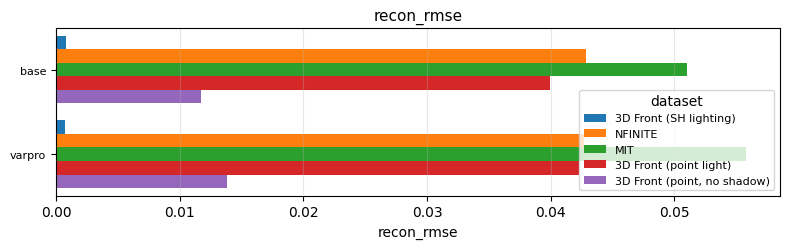

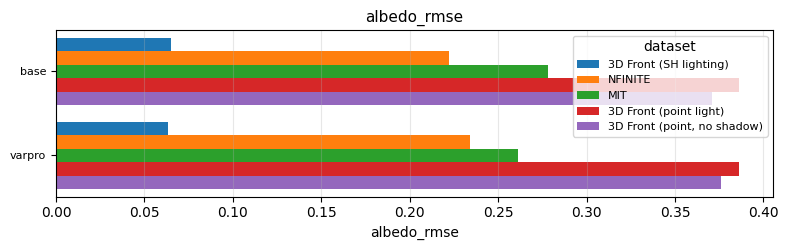

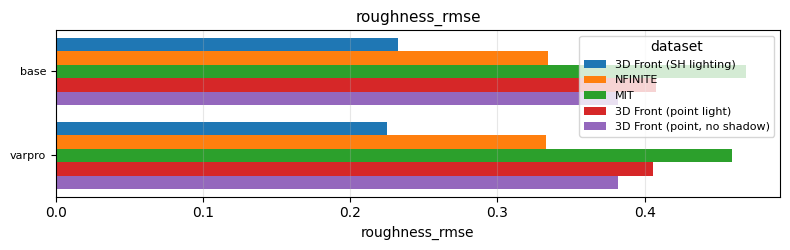

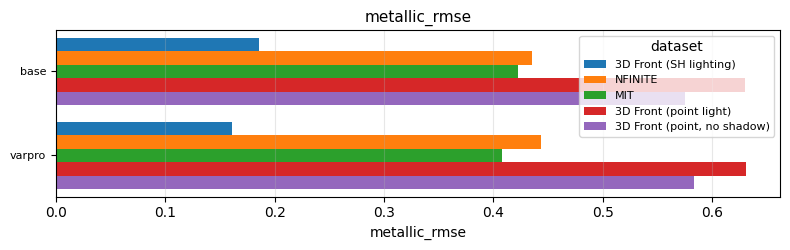

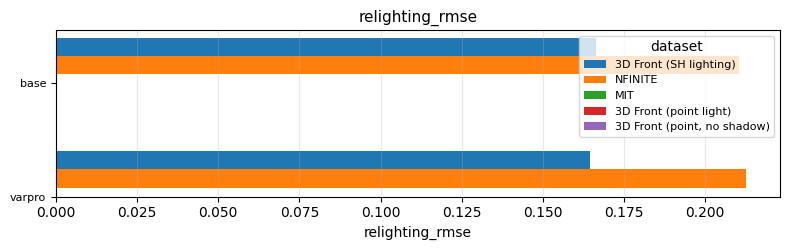

In [24]:
# One plot per metric: y = config, grouped by dataset.  Filter with CONFIGS_SHOW (cell above)
# or pass configs=[...] here.
#   kind="bars"  -> grouped horizontal bar chart
#   kind="lines" -> each dataset is points connected by a line across the configs
def per_metric_hbars(df, metrics=METRICS, kind="lines", configs=None):
    metrics  = [m for m in metrics if m in df.columns]
    datasets = sorted(df.dataset.unique())
    configs  = config_order(set(df.config), keep=configs)        # filtered by CONFIGS_SHOW
    y        = np.arange(len(configs))
    h        = 0.8 / max(len(datasets), 1)
    colors   = plt.get_cmap("tab10")(np.linspace(0, 1, 10))
    for met in metrics:
        fig, ax = plt.subplots(figsize=(8, max(2.6, 0.42 * len(configs))))
        for di, dset in enumerate(datasets):
            means = np.array([df[(df.dataset == dset) & (df.config == c)][met].mean() for c in configs])
            if kind == "lines":
                ax.plot(means, y, marker="o", ms=5, lw=1.6, label=dlabel(dset), color=colors[di % 10])
            else:
                ax.barh(y + di * h, means, height=h, label=dlabel(dset), color=colors[di % 10])
        ax.set_yticks(y if kind == "lines" else y + h * (len(datasets) - 1) / 2)
        ax.set_yticklabels(configs, fontsize=8)
        ax.invert_yaxis()                                   # first config on top
        ax.set_xlabel(met); ax.set_title(met, fontsize=11)
        ax.grid(axis="x", alpha=0.3)
        ax.legend(fontsize=8, title="dataset")
        plt.tight_layout(); plt.show()

KIND = "bars"                                              # "bars" or "lines"
per_metric_hbars(df, kind=KIND)

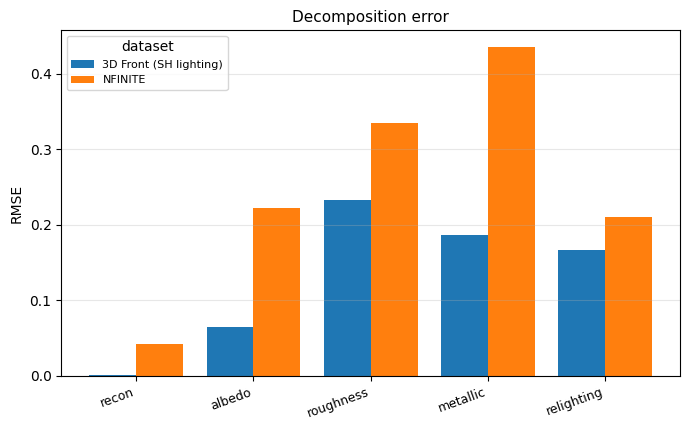

In [25]:
# ONE plot, ONE config (default "base"): x-groups = metrics, bars within a group = datasets.
CONFIG_ONE = "base"
# Which datasets to show and in what order (None = all, alphabetical). A list both FILTERS and
# SORTS, e.g. DATASETS_SHOW = ["infinite", "mit", "point"]
# DATASETS_SHOW = None
DATASETS_SHOW = ["ct_sh_env", "infinite"]

def single_config_bars(df, config=CONFIG_ONE, metrics=METRICS, datasets=None, title=None):
    present = set(df.config)
    if config not in present:
        raise ValueError(f"config {config!r} not found. available: {sorted(present)}")
    metrics = [m for m in metrics if m in df.columns]
    order   = datasets if datasets is not None else DATASETS_SHOW
    avail   = set(df.dataset.unique())
    datasets = [d for d in order if d in avail] if order is not None else sorted(avail)
    sub     = df[df.config == config]
    x       = np.arange(len(metrics))
    n       = max(len(datasets), 1)
    w       = 0.8 / n
    colors  = plt.get_cmap("tab10")(np.linspace(0, 1, 10))
    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(metrics)), 4.4))
    for di, d in enumerate(datasets):
        s = sub[sub.dataset == d]
        means = np.array([s[m].mean() for m in metrics])
        ax.bar(x + (di - (n - 1) / 2) * w, means, width=w, label=dlabel(d), color=colors[di % 10])
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_rmse", "") for m in metrics], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("RMSE"); ax.set_title(f"config = {config}  (mean over scenes)" if title==None else title, fontsize=11)
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8, title="dataset")
    plt.tight_layout(); plt.show()

single_config_bars(df, config=CONFIG_ONE, title="Decomposition error")

# MIT real scene — with vs without regularization

Decomposition of a real (non-generated) MIT multi-illumination scene, comparing the regularized
config against no regularization. Rows = with / without reg; columns = GT image, its reconstruction,
albedo, roughness (grey), metallic (grey). Prints recon RMSE over all images and for the shown image.

with         recon RMSE  all-images=0.0550  img1=0.0463
without      recon RMSE  all-images=0.0441  img1=0.0397


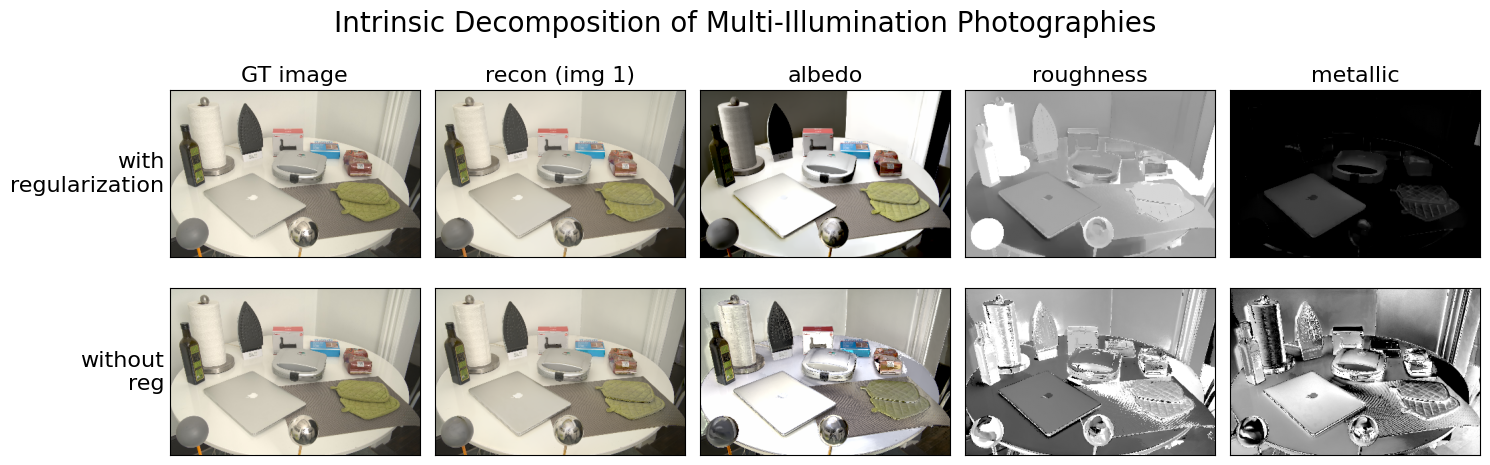

In [ ]:
from idr.data.scene_io import load_scene, linear_to_srgb

MIT_ROOT   = REPO / "local_datasets" / "canonical" / "MIT-train"
SCENE      = "marlborough_kitchen1"
REG_CFG    = "metallic_l1_seg_tv_all_light_mono"
NOREG_CFG  = "noreg"
SHOW_IMG   = 1                       # which observed light to display + report individually

def _load_run(scene, config):
    rd = RESULTS_ROOT / "mit" / scene / config
    if not (rd / "results.json").exists():
        return None, rd
    r  = json.loads((rd / "results.json").read_text())
    ds = int(r["cfg"].get("downsample", 1) or 1)
    sc = load_scene(MIT_ROOT / scene, gt_npy=True)
    mask = sc["mask_np"][::ds, ::ds]
    obs  = sc["images"][SHOW_IMG][::ds, ::ds]                     # observed (linear)
    recon = np.load(rd / "reconstructions" / f"recon_light_{SHOW_IMG:03d}.npy")
    est = dict(albedo=np.load(rd / "albedo_scaled.npy"),
               roughness=np.load(rd / "roughness_est.npy")[..., 0],
               metallic=np.load(rd / "metallic_est.npy")[..., 0])
    # NB: use np.subtract into a fresh float64 array — `recon - obs` (contiguous f32 minus a
    # non-contiguous view) mutates recon in place on this numpy build, corrupting the display.
    resid = np.subtract(np.asarray(recon, np.float64), np.asarray(obs, np.float64))
    rmse_img = float(np.sqrt((resid[mask] ** 2).mean()))
    return dict(obs=obs, recon=recon, mask=mask, rmse_all=r["metrics"].get("recon_rmse"),
                rmse_img=rmse_img, **est), rd

def mit_reg_panel(scene=SCENE, reg=REG_CFG, noreg=NOREG_CFG):
    # rows = [("with reg\n(" + reg + ")", reg), ("without reg\n(" + noreg + ")", noreg)]
    rows = [("with\nregularization",reg), ("without\nregularization", noreg)]
    loaded = []
    for label, cfg in rows:
        data, rd = _load_run(scene, cfg)
        if data is None:
            print(f"MISSING: {rd}\n  run: python scripts/canonical_decomp_batch.py --datasets mit "
                  f"--views {scene} --configs {reg} {noreg}")
            return
        loaded.append((label, data))
    cols = ["GT image", f"recon (img {SHOW_IMG})", "albedo", "roughness", "metallic"]
    fig, axes = plt.subplots(2, 5, figsize=(15, 5))
    def tm(x): return np.clip(linear_to_srgb(np.clip(x, 0, 1)), 0, 1)
    for ri, (label, d) in enumerate(loaded):
        bg = ~d["mask"]
        panels = [tm(d["obs"]), tm(d["recon"]), tm(d["albedo"]), d["roughness"], d["metallic"]]
        for ci, (ax, img, col) in enumerate(zip(axes[ri], panels, cols)):
            if ci < 3:
                disp = img.copy(); disp[bg] = 1.0; ax.imshow(disp)
            else:
                disp = np.where(d["mask"], img, np.nan)
                ax.imshow(disp, cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if ri == 0: ax.set_title(col, fontsize=16)
        axes[ri][0].set_ylabel(label, fontsize=16, rotation=0, ha="right", va="center")
        print(f"{label.splitlines()[0]:12} recon RMSE  all-images={d['rmse_all']:.4f}  "
              f"img{SHOW_IMG}={d['rmse_img']:.4f}")
    # fig.suptitle(f"MIT / {scene} — decomposition", fontsize=20)
    fig.suptitle(f"Intrinsic Decomposition of Multi-Illumination Photographies", fontsize=20)
    plt.tight_layout(); 
    plt.show()

mit_reg_panel()

# MIT generated relights — marlborough_kitchen1

The real GT image (first observed light) next to 4 generated relights, one row per generation config
(`neg_shadow_light`, `GPT`) from `local_datasets/canonical/MIT_GENERATED/<gen>/marlborough_kitchen1`.

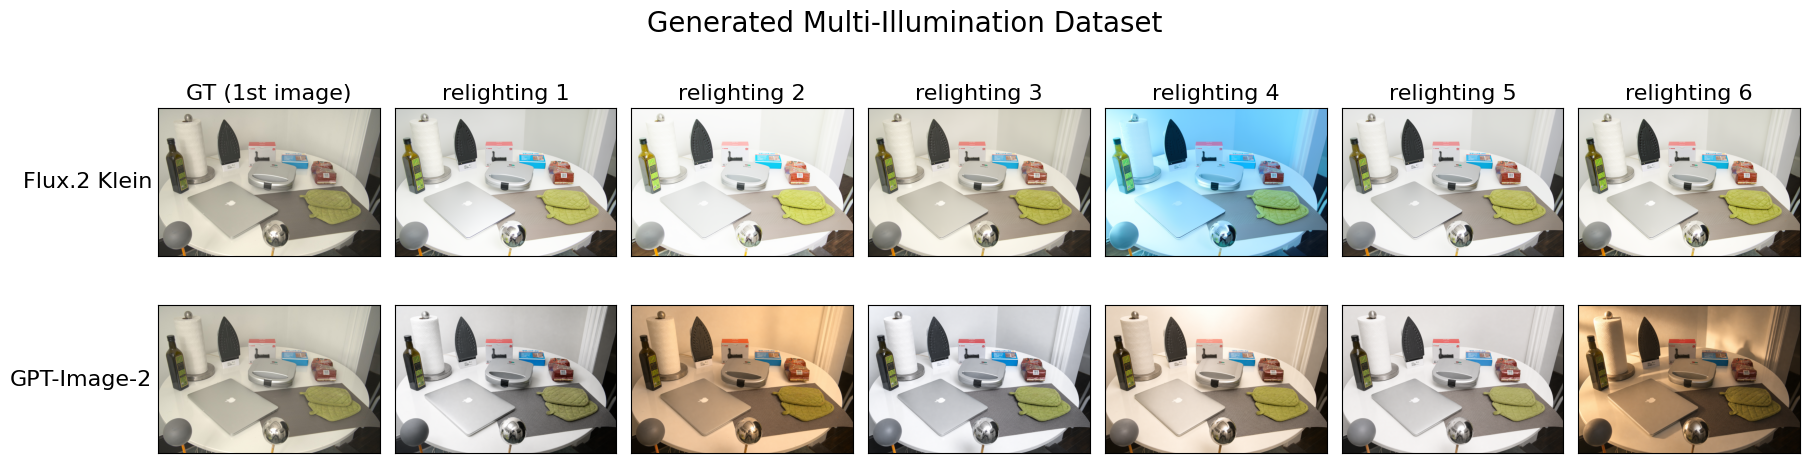

In [42]:
from PIL import Image

GEN_SCENE    = "marlborough_kitchen1"
GEN_CONFIGS  = ["neg_shadow_light", "GPT"]
GEN_LABELS   = {"neg_shadow_light": "Flux.2 Klein", "GPT": "GPT-Image-2"}   # y-axis (row) names
N_GEN        = 6                                   # how many generated relights per row
MIT_GEN_ROOT = REPO / "local_datasets" / "canonical" / "MIT_GENERATED"
GT_IMG_PATH  = REPO / "local_datasets" / "canonical" / "MIT-train" / GEN_SCENE / "light_000.png"

def gen_relit_panel(scene=GEN_SCENE, gens=GEN_CONFIGS, n=N_GEN):
    gt = np.asarray(Image.open(GT_IMG_PATH).convert("RGB"))     # real observed (sRGB png)
    fig, axes = plt.subplots(len(gens), 1 + n, figsize=(2.6 * (1 + n), 2.6 * len(gens)), squeeze=False)
    for ri, gen in enumerate(gens):
        gdir = MIT_GEN_ROOT / gen / scene
        names = {e["index"]: e["name"] for e in json.loads((gdir / "lights.json").read_text())} \
                if (gdir / "lights.json").exists() else {}
        axes[ri][0].imshow(gt); axes[ri][0].set_xticks([]); axes[ri][0].set_yticks([])
        if ri == 0: axes[ri][0].set_title("GT (1st image)", fontsize=16)
        axes[ri][0].set_ylabel(GEN_LABELS.get(gen, gen), fontsize=16, rotation=0, ha="right", va="center")
        for ci in range(n):
            ax = axes[ri][1 + ci]; lp = gdir / f"light_{ci:03d}.png"
            if lp.exists():
                ax.imshow(np.asarray(Image.open(lp).convert("RGB")))
                if ri == 0: ax.set_title(f"relighting {ci + 1}", fontsize=16)
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center"); 
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Generated Multi-Illumination Dataset", fontsize=20)
    plt.tight_layout(); plt.show()

gen_relit_panel()

# MIT marlborough_kitchen1 — method comparison + hard relight

Estimated intrinsics and a hard directional relight (narrow env-map lobe) for four methods on the
same scene: the regularized CT decomposition run on the **Flux.2 Klein** (neg_shadow_light) and
**GPT** generated datasets, plus the single-image **Marigold** and **RGB→X** predictors (their
`marigold/` and `rgbx/` subfolders in the MIT-train scene). Columns: GT (real MIT light_000, shared),
albedo, roughness, metallic, relighting. All relit at ds=4 through the shared GT normals.

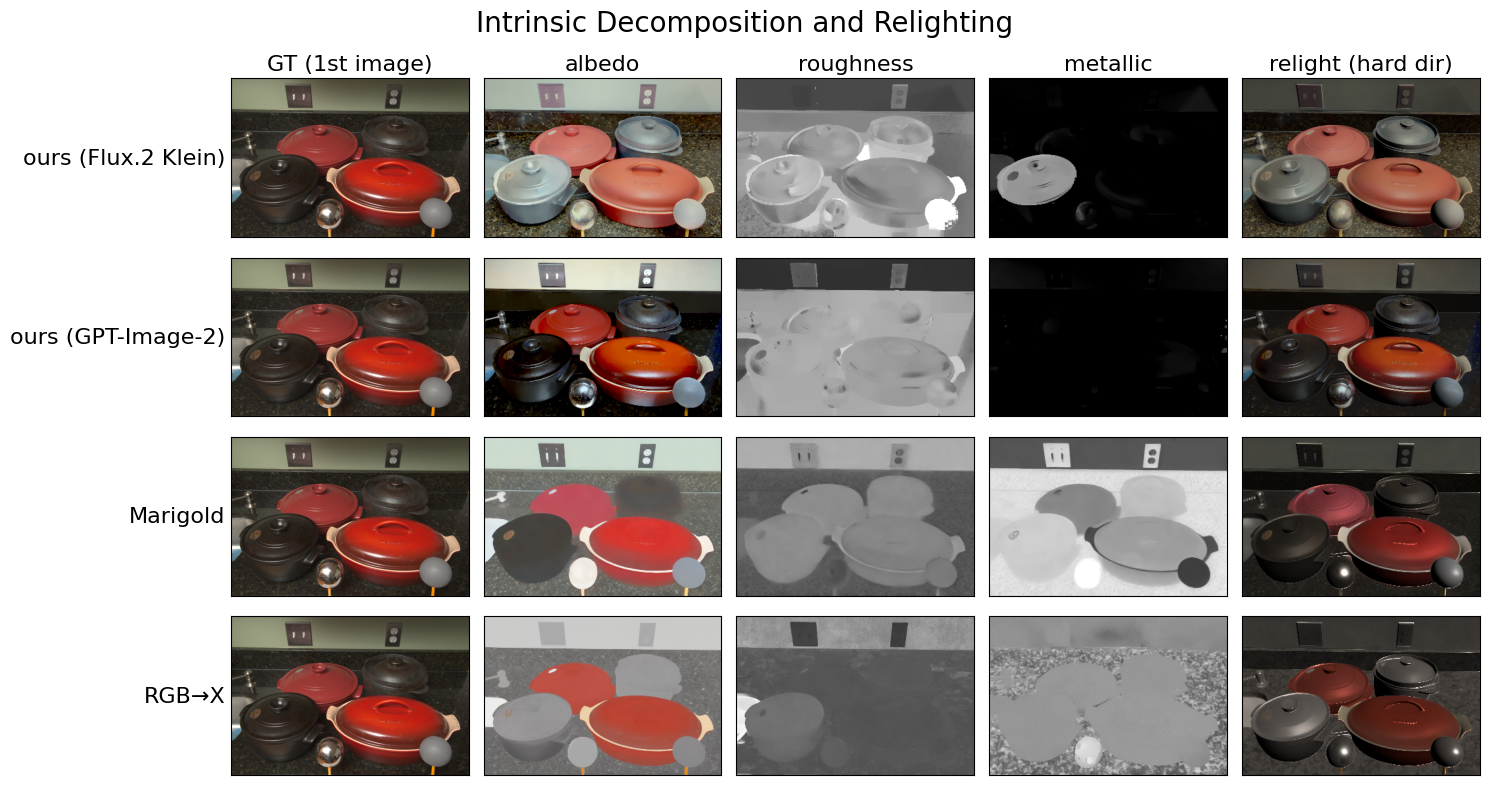

In [28]:
from idr.data.scene_io import load_scene, linear_to_srgb, srgb_to_linear
from canonical_relight_render import Relighter, load_est_intrinsics, load_gt_intrinsics
import torch
from PIL import Image

# CMP_SCENE = "marlborough_kitchen1"
# CMP_SCENE = "everett_kitchen12"
CMP_SCENE = "kingston_kitchen18"
CMP_DS    = 4
REG_CFG   = "metallic_l1_seg_tv_all_light_mono"
GEN_ROOT  = RESULTS_ROOT.parent / "generated_config_study" / "MIT"     # results/generated_config_study/MIT
MIT_TRAIN = REPO / "local_datasets" / "canonical" / "MIT-train" / CMP_SCENE
# relight: a hard directional light rendered as a narrow env-map lobe
REL_AZ, REL_EL, REL_SIGMA = 40.0, 35.0, 4.0

# rows: (label, kind, path).  kind="decomp" -> CT run dir; "pred" -> marigold/rgbx subfolder
METHODS = [
    ("ours (Flux.2 Klein)", "decomp", GEN_ROOT / "neg_shadow_light" / CMP_SCENE / REG_CFG),
    ("ours (GPT-Image-2)",          "decomp", GEN_ROOT / "GPT"              / CMP_SCENE / REG_CFG),
    ("Marigold",     "pred",   MIT_TRAIN / "marigold"),
    ("RGB\u2192X",  "pred",   MIT_TRAIN / "rgbx"),
]

def _intr(kind, path, ds):
    """intrinsics at the ds grid: albedo (H,W,3) LINEAR, roughness/metallic (H,W,1)."""
    if kind == "decomp":
        e = load_est_intrinsics(path)                 # albedo_scaled (linear), *_est (already ds)
        return dict(albedo=e["albedo"], roughness=e["roughness"], metallic=e["metallic"])
    a = srgb_to_linear(np.load(path / "albedo.npy").astype(np.float32))[::ds, ::ds]     # predictors: sRGB->linear
    r = np.load(path / "roughness.npy").astype(np.float32)[::ds, ::ds]
    m = np.load(path / "metallic.npy").astype(np.float32)[::ds, ::ds]
    return dict(albedo=a, roughness=r, metallic=m)

def method_compare_panel():
    gt_geo = load_gt_intrinsics(MIT_TRAIN, CMP_DS)                     # normals+mask at ds (shared)
    rel = Relighter(gt_geo["normals"], gt_geo["mask"], DEVICE, torch.float32, True)
    mask = gt_geo["mask"]
    gt_img = np.asarray(Image.open(MIT_TRAIN / "light_000.png").convert("RGB"))   # shared GT image
    cols = ["GT (1st image)", "albedo", "roughness", "metallic", f"relight (hard dir)"]
    rows = [(lab, _intr(kind, path, CMP_DS)) for lab, kind, path in METHODS]
    def tm(x): return np.clip(linear_to_srgb(np.clip(x, 0, 1)), 0, 1)
    fig, axes = plt.subplots(len(rows), 5, figsize=(15, 2 * len(rows)))
    for ri, (lab, intr) in enumerate(rows):
        relit = rel.render_env(intr, REL_AZ, REL_EL, sigma_deg=REL_SIGMA)
        panels = [gt_img, tm(intr["albedo"]), intr["roughness"][..., 0], intr["metallic"][..., 0], tm(relit)]
        for ci, (ax, img) in enumerate(zip(axes[ri], panels)):
            if ci in (2, 3):                                          # roughness/metallic grayscale
                ax.imshow(np.where(mask, img, np.nan), cmap="gray", vmin=0, vmax=1)
            else:
                disp = img.copy()
                if ci in (1, 4): disp[~mask] = 1.0
                ax.imshow(disp)
            ax.set_xticks([]); ax.set_yticks([])
            if ri == 0: ax.set_title(cols[ci], fontsize=16)
        axes[ri][0].set_ylabel(lab, fontsize=16, rotation=0, ha="right", va="center")
    fig.suptitle(f"Intrinsic Decomposition and Relighting", fontsize=20)
    # fig.suptitle(f"MIT / {CMP_SCENE} — intrinsics + hard directional relight (env map, "                 
                #  f"az={REL_AZ:.0f} el={REL_EL:.0f})", fontsize=16)
    plt.tight_layout(); plt.show()

method_compare_panel()

# Summary table — recon / intrinsic RMSE / relighting

One row per experimental condition (mean over scenes). Each row maps to a results glob under
`results/`; rows whose runs aren't present yet show "—". Metric columns: recon, albedo, roughness,
metallic (RMSE) and held-out relighting RMSE (blank where the dataset has no GT lighting).

In [ ]:
RESULTS = RESULTS_ROOT.parent      # results/
TABLE_METRICS = ["recon_rmse", "albedo_rmse", "roughness_rmse", "metallic_rmse", "relighting_rmse"]

# (row label, results glob relative to results/). Edit patterns to point at the runs you want.
# (3D Front, no reg, GT normals, SH3 decomp, FOV = 60 (GT))
TABLE_ROWS = [
    ("base",   "canonical_ablation/ct_sh_env/*/base/results.json"),
    ("SH2 decomp",               "canonical_ablation/ct_sh_env/*/sh2/results.json"),
    ("pred. normals",     "marigold_normal_study/light_mono/*/normal_000/results.json"),
    ("Cycles",     "canonical_ablation/point/*/base/results.json"),
    ("3D-Front point, shadow, GT normals", "canonical_ablation/point/*/base/results.json"),
    ("NFINITE",           "canonical_ablation/infinite/*/base/results.json"),
    ("regularized", "canonical_ablation/ct_sh_env/*/metallic_l1_seg_tv_all_light_mono/results.json"),
    ("FOV=90",    "fov_study/ct_sh_env/fov90/*/results.json"),
]

def _row_metrics(pattern):
    vals = {m: [] for m in TABLE_METRICS}; n = 0
    for fp in sorted(RESULTS.glob(pattern)):
        try:
            met = json.loads(fp.read_text()).get("metrics", {})
        except Exception:
            continue
        n += 1
        for m in TABLE_METRICS:
            v = met.get(m)
            if isinstance(v, (int, float)) and v == v:   # v==v drops NaN (some scenes diverge)
                vals[m].append(v)
    out = {"#": n}
    for m in TABLE_METRICS:
        out[m] = float(np.mean(vals[m])) if vals[m] else np.nan
    return out

def summary_table(rows=TABLE_ROWS):
    df = pd.DataFrame({lab: _row_metrics(pat) for lab, pat in rows}).T
    df = df[["#"] + TABLE_METRICS]
    disp = df.copy()
    disp.columns = ["#scenes"] + [m.replace("_rmse", "") for m in TABLE_METRICS]
    for c in disp.columns[1:]:
        disp[c] = disp[c].map(lambda x: "—" if pd.isna(x) else f"{x:.4f}")
    disp["#scenes"] = disp["#scenes"].astype(int)
    display(disp)
    print("\n* Marigold-normals row uses the light_mono config (not base) — see audit; rerun at "
          "noreg for a clean no-reg comparison.")
    return df

table_df = summary_table()

In [38]:
# LaTeX version of the table (no #scenes column) — copy-paste the printed output.
def table_latex(df=None, floatfmt="{:.3f}", na="--"):
    df = table_df if df is None else df
    d = df.drop(columns=["#"]).copy()
    d.columns = [c.replace("_rmse", "") for c in d.columns]
    for c in d.columns:
        d[c] = d[c].map(lambda x: na if pd.isna(x) else floatfmt.format(x))
    tex = d.to_latex(escape=False, column_format="l" + "r" * len(d.columns))
    print(tex)
    return tex

_ = table_latex()

\begin{tabular}{lrrrrr}
\toprule
 & recon & albedo & roughness & metallic & relighting \\
\midrule
base & 0.001 & 0.065 & 0.232 & 0.186 & 0.166 \\
SH2 decomp & 0.002 & 0.064 & 0.242 & 0.147 & 0.154 \\
pred. normals & 0.016 & 0.160 & 0.341 & 0.446 & 0.201 \\
Cycles & 0.040 & 0.386 & 0.408 & 0.630 & -- \\
NFINITE & 0.043 & 0.222 & 0.334 & 0.435 & 0.210 \\
regularized & 0.010 & 0.066 & 0.241 & 0.248 & 0.160 \\
FOV=90 & 0.004 & 0.091 & 0.283 & 0.194 & 0.143 \\
\bottomrule
\end{tabular}



# Dataset examples — 3D-Front (CT-SH), 3D-Front (Cycles point), NFINITE

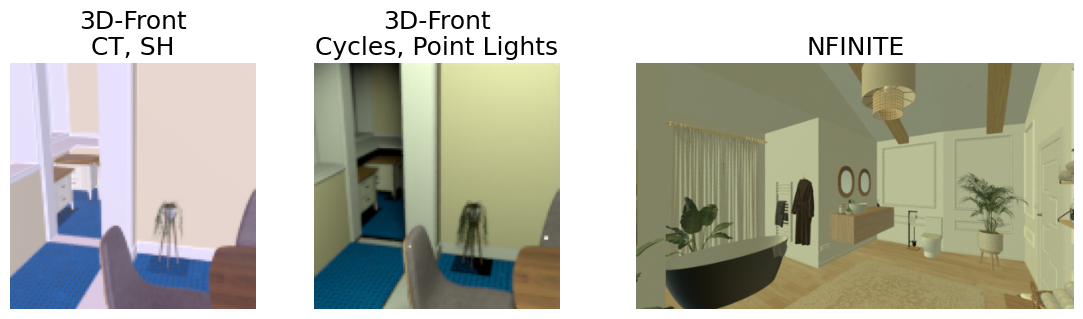

In [41]:
from idr.data.scene_io import linear_to_srgb
from PIL import Image

SH3 = REPO / "local_datasets" / "26-08-09-datasets" / "sh3"
INF = REPO / "local_datasets" / "canonical" / "INFINITE"
PANELS = [
    (SH3 / "1f19c3ef_v2" / "ct-ct_sh-frOn_env", "3D-Front\nCT, SH"),
    (SH3 / "1f19c3ef_v2" / "point_shadow",       "3D-Front\nCycles, Point Lights"),
    (INF / "bathroom_9061_sh_opaque",            "NFINITE"),
]

def _disp_light(d, stem="light_000"):
    npy = d / f"{stem}.npy"
    for ext in (".png", ".jpg", ".jpeg"):
        p = d / f"{stem}{ext}"
        if npy.exists():
            break
        if p.exists():
            return np.asarray(Image.open(p).convert("RGB"))
    a = np.load(npy)[..., :3].astype(np.float32)
    return (np.clip(linear_to_srgb(np.clip(a, 0, 1)), 0, 1) * 255).astype(np.uint8)

imgs   = [(_disp_light(d), t) for d, t in PANELS]
aspect = [im.shape[1] / im.shape[0] for im, _ in imgs]     # w/h -> equal-height layout
H = 3.0
fig, axes = plt.subplots(1, len(imgs), figsize=(H * sum(aspect), H),
                         gridspec_kw={"width_ratios": aspect, "wspace": 0.02})
for ax, (im, txt) in zip(axes, imgs):
    ax.imshow(im)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():          # no border
        sp.set_visible(False)
    ax.set_title(txt, fontsize=18, color="black", linespacing=1.1)
plt.subplots_adjust(left=0, right=1, top=0.82, bottom=0, wspace=0.02)
plt.show()